<a href="https://colab.research.google.com/github/Mattalukkal/Ai_ML/blob/main/Assignment_on_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
filepath = '/content/drive/MyDrive/Colab Notebooks/DATA/Mall_Customers.csv'
df = pd.read_csv(filepath)
df.head() # first 5 columns

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Replace '?' with NaN

In [5]:
df.replace('?', np.nan, inplace=True)


Handle Missing Values

In [9]:
# Separate numerical & categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Fill numerical with median
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical with mode
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

Remove Income Column

In [12]:
income = df['Annual Income (k$)']   # Save for later comparison
df.drop('Annual Income (k$)', axis=1, inplace=True)

KeyError: 'Annual Income (k$)'

4. Outlier Treatment (IQR Method)

In [15]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

5. Encode Categorical Variables

In [16]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()


,CustomerID,Age,Spending Score (1-100),Genre_Male
0,1,19,39,True
1,2,21,81,True
2,3,20,6,False
3,4,23,77,False
4,5,31,40,False


6. Feature Scaling

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)


7. Exploratory Data Analysis

Distribution Plot

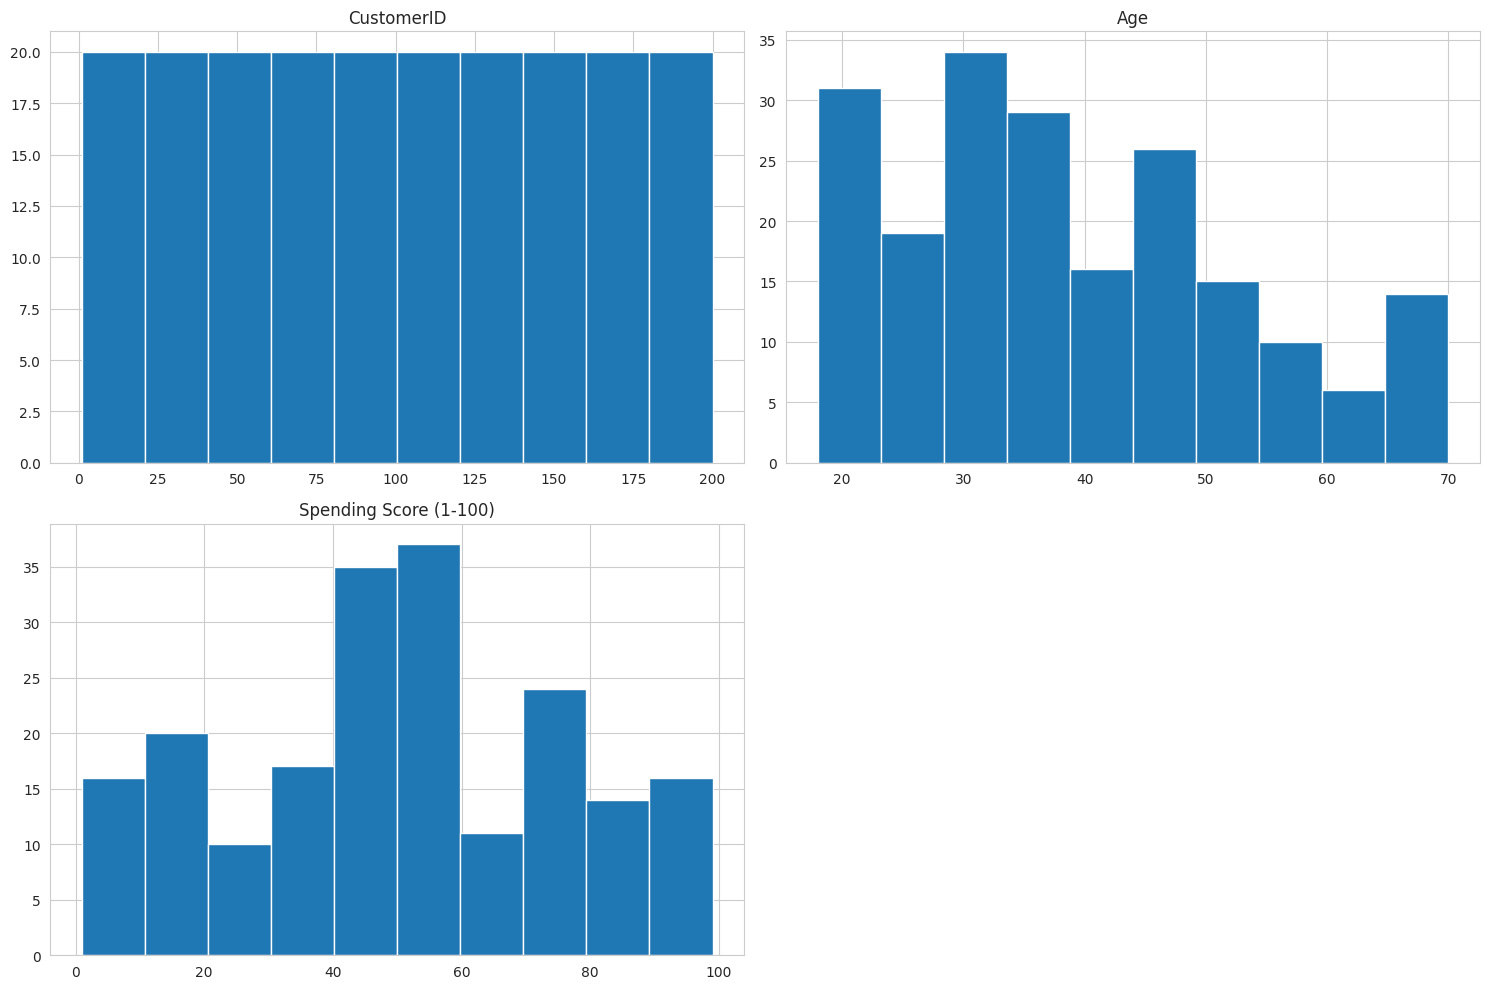

In [18]:
df_encoded.hist(figsize=(15,10))
plt.tight_layout()
plt.show()


Correlation Heatmap

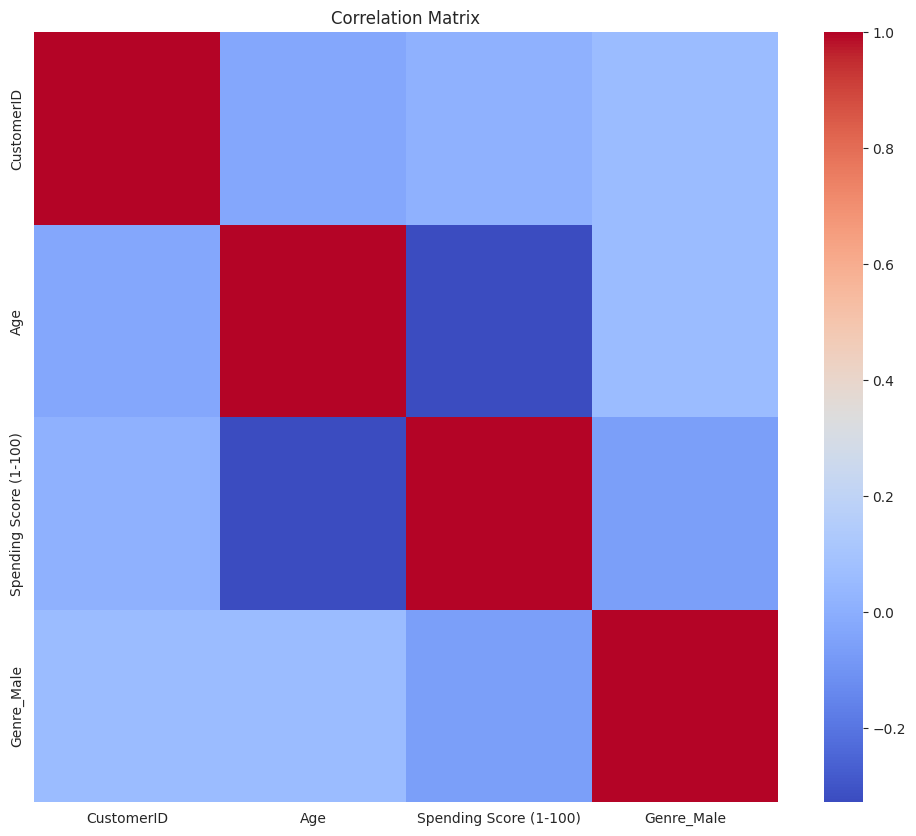

In [19]:
plt.figure(figsize=(12,10))
sns.heatmap(df_encoded.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


8. KMeans Clustering

Elbow Method

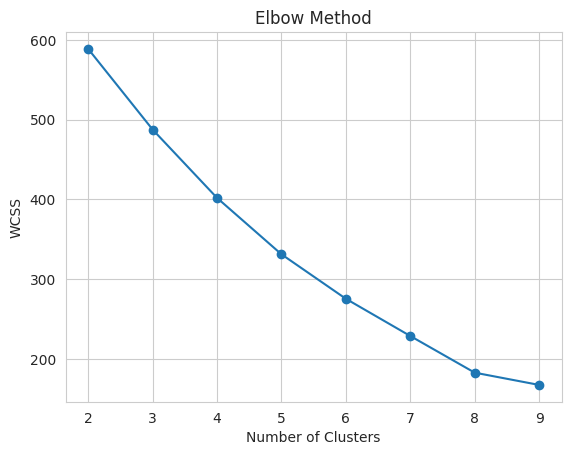

In [20]:
wcss = []

for i in range(2, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(2, 10), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()


Choose Optimal K

In [21]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)

print("Silhouette Score:", silhouette_score(X_scaled, labels))


Silhouette Score: 0.25656708729678573


9. Agglomerative Clustering

In [22]:
agg = AgglomerativeClustering(n_clusters=3)
labels_agg = agg.fit_predict(X_scaled)

print("Agglomerative Silhouette Score:", silhouette_score(X_scaled, labels_agg))


Agglomerative Silhouette Score: 0.24874864155963228


10. PCA for 2D Visualization

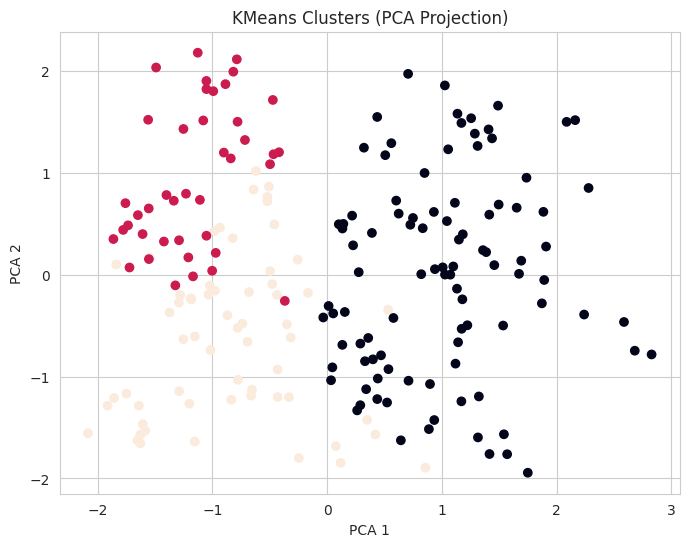

In [23]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("KMeans Clusters (PCA Projection)")
plt.show()


11. Cluster Profiling

In [24]:
 df_encoded['Cluster'] = labels
df_profile = df_encoded.groupby('Cluster').mean()

df_profile


,CustomerID,Age,Spending Score (1-100),Genre_Male
Cluster,,,,
0,104.275510,49.551020,32.969388,0.489796
1,160.048780,32.731707,80.902439,0.463415
2,54.409836,25.770492,57.245902,0.344262


12. Compare With Actual Income

In [25]:
df_original = df.copy()
df_original['Cluster'] = labels
df_original['income'] = income

pd.crosstab(df_original['Cluster'], df_original['income'])


income,15,16,17,18,19,20,21,23,24,25,28,29,30,33,34,37,38,39,40,42,43,44,46,47,48,49,50,54,57,58,59,60,61,62,63,64,65,67,69,70,71,72,73,74,75,76,77,78,79,81,85,86,87,88,93,97,98,99,101,103,113,120,126,137
Cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,2,2,0,1,0,1,2,0,1,2,1,0,1,2,1,1,3,2,2,2,3,2,2,9,1,1,1,3,1,3,5,1,2,3,0,0,3,0,2,1,1,0,2,6,1,1,1,1,3,2,1,1,1,1,1,2,1,1,1,1
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2,1,3,1,2,1,1,1,2,6,1,1,1,1,3,2,1,1,1,1,1,2,1,1,1,1
2,2,2,2,2,2,2,2,1,2,1,2,2,1,2,1,2,1,2,3,1,1,0,2,0,3,0,0,3,1,1,1,3,1,3,1,1,2,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Policy suggestions or business implications

In [ ]:
Cluster 0:
- Higher education
- Higher capital gain
- Long working hours
→ Likely high-income professionals

Cluster 1:
- Medium education
- Moderate working hours
→ Middle-class workers

Cluster 2:
- Lower education
- Low capital gain
→ Vulnerable / low-income group
